In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [26]:
df = pd.read_csv('03.BaseDPEvolucaoMensalCisp.csv', encoding='iso-8859-1', sep=';')

In [27]:
df_recuperacao_veiculo = df[['munic', 'recuperacao_veiculos']]

# agrupar por município 
df_recuperacao_veiculo = df_recuperacao_veiculo.groupby('munic').sum().reset_index().sort_values(by='recuperacao_veiculos', ascending=False)
df_recuperacao_veiculo

df_recuperacao_veiculo_total = df_recuperacao_veiculo['recuperacao_veiculos'].sum()

top10_municipios = df_recuperacao_veiculo.iloc[:10]

top10_municipios

,munic,recuperacao_veiculos
68,Rio de Janeiro,269057
23,Duque de Caxias,42959
78,São Gonçalo,39574
81,São João de Meriti,19341
50,Nova Iguaçu,17217
48,Niterói,15417
6,Belford Roxo,14164
13,Campos dos Goytacazes,5334
47,Nilópolis,5257
43,Mesquita,5000


Conseguimos observar que os 3 primeiros municipios com maior número de roubos também são os que mais possuem recuperação, na mesma ordem, porém as coisas mudam a partir de Nova Iguaçu, que possui mais roubos que São João de Meriti, mas não necessariamente um maior número de recuperações, demonstrando menor eficácia da polícia em Nova Iguaçu.

In [28]:
df_roubo_ano = df.groupby('ano')['roubo_veiculo'].sum().reset_index()

df_roubo_ano

,ano,roubo_veiculo
0,2003,33531
1,2004,32408
2,2005,32690
3,2006,34324
4,2007,31490
5,2008,27847
6,2009,25036
7,2010,20052
8,2011,18773
9,2012,22065


In [29]:
df_recuperacao_ano = df.groupby('ano')['recuperacao_veiculos'].sum().reset_index()

df_recuperacao_ano

,ano,recuperacao_veiculos
0,2003,29947
1,2004,26522
2,2005,26332
3,2006,26073
4,2007,24452
5,2008,21060
6,2009,19913
7,2010,16568
8,2011,16142
9,2012,17446


1. O ano com maior recuperação de veículos foi em 2017, também ano recorde de roubo de veículos.
2. No geral a tendência foi mais de queda, mas não necessariamente todos os anos. Os anos de 2012 a 2017 teve um crescimento de roubos e recuperações de veículos, após esse período teve um declínio novamente.
3. Majoritariamente sim, mas nem sempre, por exemplo: em 2023 teve um declínio de roubos, porém um aumento de recuperações. Mas 2023 foi mais exceção do que regra. Em 2024 a queda recorde de roubos levou a uma queda recorde de recuperações.

In [30]:
df_recuperacao_ano_array = np.array(df_recuperacao_ano['recuperacao_veiculos'])

media_recuperacoes = np.mean(df_recuperacao_ano_array)

amplitude = np.max(df_recuperacao_ano_array) - np.min(df_recuperacao_ano_array)                     
media_recuperacoes = np.mean(df_recuperacao_ano_array)
mediana_recuperacoes = np.median(df_recuperacao_ano_array)

q1 = np.quantile(df_recuperacao_ano_array, 0.25)
q2 = np.quantile(df_recuperacao_ano_array, 0.50, method='weibull')
q3 = np.quantile(df_recuperacao_ano_array, 0.75)
iqr = (q3 - q1)


limite_superior = q3 + (1.5 * iqr)

limite_inferior = q1 - (1.5 * iqr)

desvio = np.std(df_recuperacao_ano_array)
variancia = np.var(df_recuperacao_ano_array)
distancia_var_media = abs(variancia/media_recuperacoes**2)

cv = desvio/media_recuperacoes

assimetria = df_recuperacao_ano['recuperacao_veiculos'].skew()
kurt = df_recuperacao_ano['recuperacao_veiculos'].kurtosis()


In [31]:
print(f'Média: {media_recuperacoes}')
print(f'Mediana: {mediana_recuperacoes}')
print(f'Min: {np.min(df_recuperacao_ano_array)}')
print(f'Max: {np.max(df_recuperacao_ano_array)}')
print(f'Q1: {q1}')
print(f'Q2: {q2}')
print(f'Q3: {q3}')
print(f'Limite Inferior: {limite_inferior}')
print(f'Limite Superior: {limite_superior}')
print(f'Distância Variância/Média: {distancia_var_media}')
print(f'Coeficiente de Variação: {cv}')
print(f'Assimetria: {assimetria}')
print(f'Curtose: {kurt}')

Média: 22340.409090909092
Mediana: 22509.0
Min: 9626
Max: 37630
Q1: 16248.5
Q2: 22509.0
Q3: 26474.5
Limite Inferior: 909.5
Limite Superior: 41813.5
Distância Variância/Média: 0.10353487814560516
Coeficiente de Variação: 0.3217683610077367
Assimetria: 0.34941843072254636
Curtose: -0.2906757120045089


In [32]:
df_recuperacao_outliers_inferiores = df_recuperacao_ano[df_recuperacao_ano['recuperacao_veiculos'] < limite_inferior]
df_recuperacao_outliers_superiores = df_recuperacao_ano[df_recuperacao_ano['recuperacao_veiculos'] > limite_superior]

In [33]:
if df_recuperacao_outliers_inferiores.empty:
    print('Não há outliers inferiores.')
else:
    print(df_recuperacao_outliers_inferiores.sort_values(by='recuperacao_veiculos', ascending=True))

if df_recuperacao_outliers_superiores.empty:
    print('Não há outliers superiores.')
else:
    print(df_recuperacao_outliers_superiores.sort_values(by='recuperacao_veiculos', ascending=False))

Não há outliers inferiores.
Não há outliers superiores.


Text(0.5, 1.0, 'Roubo de veículos por ano')

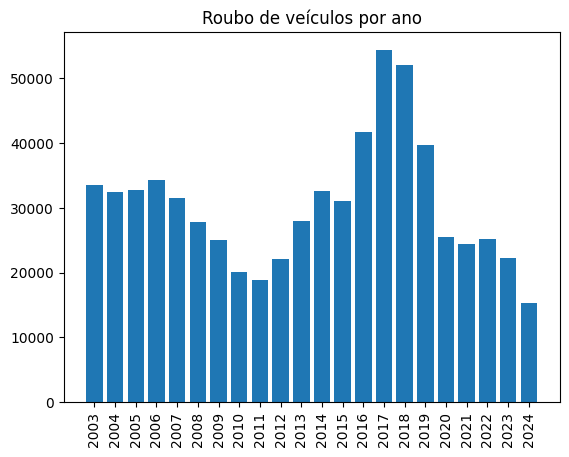

In [34]:
plt.bar(df_roubo_ano['ano'].astype(str), df_roubo_ano['roubo_veiculo'])
plt.xticks(rotation=90)
plt.title('Roubo de veículos por ano')

Text(0.5, 1.0, 'Recuperação de veículos por ano')

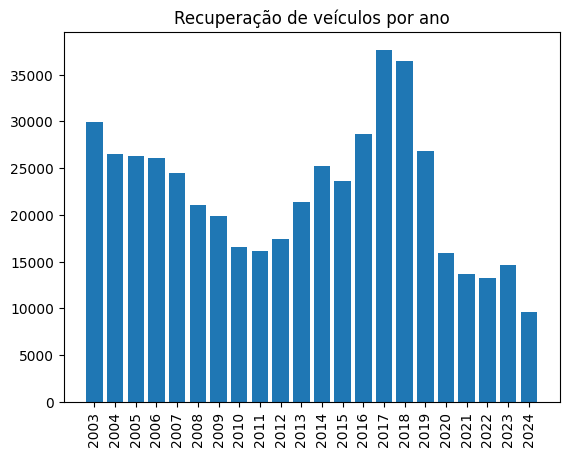

In [35]:
plt.bar(df_recuperacao_ano['ano'].astype(str), df_recuperacao_ano['recuperacao_veiculos'])
plt.xticks(rotation=90)
plt.title('Recuperação de veículos por ano')

Comparando ambos os gráficos, conseguimos ver que existe uma correlação entre roubos e recuperações, mas não total.
O pico de roubos foi entre 2017 e 2018, o mesmo pico de recuperações. Essa correlação também existe nos anos de menor roubo e de recuperação (2010, 2011 e 2024). É óbvio que com um maior número de carros roubados, também há um maior número de carros a serem recuperados, logo temos uma explicação desse fenômeno. Mas também temos anos que essa correlação não é total, como em 2022-2023, o que pode significar que a atividade da polícia também foi mais(ou menos) eficientes em anos como estes.

In [36]:
df_recuperacao_outliers_inferiores2 = df_recuperacao_veiculo[df_recuperacao_veiculo['recuperacao_veiculos'] < limite_inferior]
df_recuperacao_outliers_superiores2 = df_recuperacao_veiculo[df_recuperacao_veiculo['recuperacao_veiculos'] > limite_superior]

if df_recuperacao_outliers_inferiores2.empty:
    print('Não há outliers inferiores.')
else:
    print(df_recuperacao_outliers_inferiores2.sort_values(by='recuperacao_veiculos', ascending=True))

if df_recuperacao_outliers_superiores2.empty:
    print('Não há outliers superiores.')
else:
    print(df_recuperacao_outliers_superiores2.sort_values(by='recuperacao_veiculos', ascending=False))

                                                munic  recuperacao_veiculos
57                                    Piraí;Pinheiral                    24
35                                     Laje do Muriaé                    24
66                                     Rio das Flores                    28
83                              São Sebastião do Alto                    35
22                                        Duas Barras                    54
14  Campos dos Goytacazes;São Francisco de Itabapoana                    55
86                                  Trajano de Morais                    62
24                        Engenheiro Paulo de Frontin                    64
69                               Santa Maria Madalena                    72
58                                        Porciúncula                    72
12                                            Cambuci                    75
46                               Natividade;Varre-Sai                    81
45          

Text(0.5, 1.0, 'Ranking das cidades com outliers superiores')

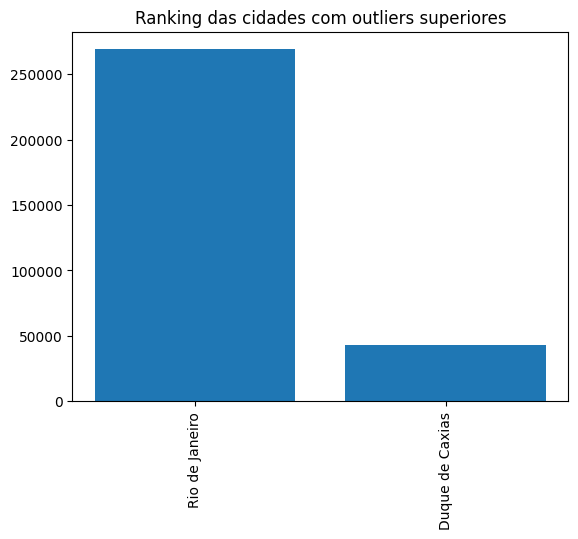

In [37]:
plt.bar(df_recuperacao_outliers_superiores2['munic'], df_recuperacao_outliers_superiores2['recuperacao_veiculos'])
plt.xticks(rotation=90)
plt.title('Ranking das cidades com outliers superiores')